Task 1: Introduction of Data Story.
Well-logging is an essential geophysical method of acquiring a high-resolution of the physical characteristics of geologic formations through the descent of special sensors into a borehole. This enables the researchers to scan the subsurface in situ, and gives a continuous profile of the interior of the earth which could not have been measured solely using the surface measurements. Geophysicists can characterize the lithology, fluid content and structural integrity of the formation of a specific depth (z) through the measurement of natural radioactivity, electrical resistivity, and bulk density.
In this Data Story, I will be using well-logging data collected by the International Ocean Discovery Program (IODP) Expedition 372A at hole U1517A. This was a mission aimed at exploring the correlation between the gas hydrates and creeping landslides at the Hikurangi Margin off the coast of New Zealand. Such datasets are normally represented as one-dimensional (1D) spatial series, with each physical measurement identified by its depth below the sea bottom (mbsf). These observations are important to understand both in scientific research, including climate modeling through the use of methane hydrates, and in societal practice, including determining energy sources and determining geohazard risks such as submarine slope failures. To manipulate and analyze this high-resolution information, standard data processing and visualization packages like the Python pandas library to manipulate data and matplotlib to visualize vertical profiles are used.


In [1]:
pip install pandas numpy matplotlib --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:


import pandas as pd
import numpy as np
import os

path = "/home/kadidamariko/work/classes/GPGN268/coursework-Mariko/ds01-well-log/data/iodp-logging-data/"

def load_well_log(filename):
    full_path = os.path.join(path, filename)
    
    # Find the data start row
    with open(full_path, 'r') as f:
        lines = f.readlines()
        skip_to = 0
        for i, line in enumerate(lines):
            if 'depth' in line.lower():
                skip_to = i
                break
                
    # Read and drop the units row
    temp_df = pd.read_csv(full_path, skiprows=skip_to)
    temp_df = temp_df.drop(0)
    
    # Clean up column names (lowercase and strip spaces)
    temp_df.columns = [c.lower().strip() for c in temp_df.columns]
    
    # Find ANY column that has the word 'depth' in it and rename it to 'depth'
    for col in temp_df.columns:
        if 'depth' in col:
            temp_df = temp_df.rename(columns={col: 'depth'})
            break # Found it!
            
    return temp_df.apply(pd.to_numeric, errors='coerce')

# Load the four core files
df_gr = load_well_log('372-U1517A_gr-nscope.csv')
df_res = load_well_log('372-U1517A_res-atten-nscope.csv')
df_den = load_well_log('372-U1517A_den-nscope.csv')
df_por = load_well_log('372-U1517A_por-nscope.csv')

# Merge them all on the standardized 'depth' column
df = pd.merge(df_gr, df_res, on='depth', how='outer')
df = pd.merge(df, df_den, on='depth', how='outer')
df = pd.merge(df, df_por, on='depth', how='outer')

# Final Cleanup: replace the error marker and sort
df = df.replace(-999.25, np.nan)
df = df.sort_values('depth').reset_index(drop=True)

# Display result
df.head(10)

/home/kadidamariko/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kadidamariko/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,depth,grma,a16b,a16h,a16l,a22b,a22h,a22l,a28b,a28h,a28l,a34b,a34h,a34l,a40b,a40h,a40l,rhon,bphi,tnph
0,0.1348,NaN,0.586082,0.605559,0.586082,0.599109,0.616815,0.599109,0.594265,0.620935,0.594265,0.587228,0.620780,0.587228,0.591475,0.622784,0.591475,1.402081,NaN,NaN
1,0.2872,NaN,0.621122,0.627951,0.621121,0.634826,0.640407,0.634826,0.627405,0.643460,0.627405,0.618603,0.642074,0.618603,0.624427,0.644852,0.624427,1.385705,NaN,NaN
2,0.4396,1.550004,0.657758,0.656639,0.657758,0.671563,0.670512,0.671563,0.667113,0.677705,0.667113,0.660469,0.679783,0.660468,0.665547,0.682812,0.665547,1.358488,78.2805,76.583
3,0.4701,1.891901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5006,2.233648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.5311,2.575546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.5616,2.917978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.5920,3.260399,0.689537,0.694921,0.689537,0.705435,0.706657,0.705435,0.704482,0.714458,0.704482,0.699302,0.719581,0.699301,0.703513,0.725789,0.703513,1.354235,76.7572,73.069
8,0.6225,3.882167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.6530,4.503662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
output_dir = "../processed_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df.to_csv(os.path.join(output_dir, "U1517A_combined_logs.csv"), index=False)

print(f"Cleaned data saved to {output_dir}!")

Cleaned data saved to ../processed_data!


In [4]:
print(df.columns.tolist())


['depth', 'grma', 'a16b', 'a16h', 'a16l', 'a22b', 'a22h', 'a22l', 'a28b', 'a28h', 'a28l', 'a34b', 'a34h', 'a34l', 'a40b', 'a40h', 'a40l', 'rhon', 'bphi', 'tnph']


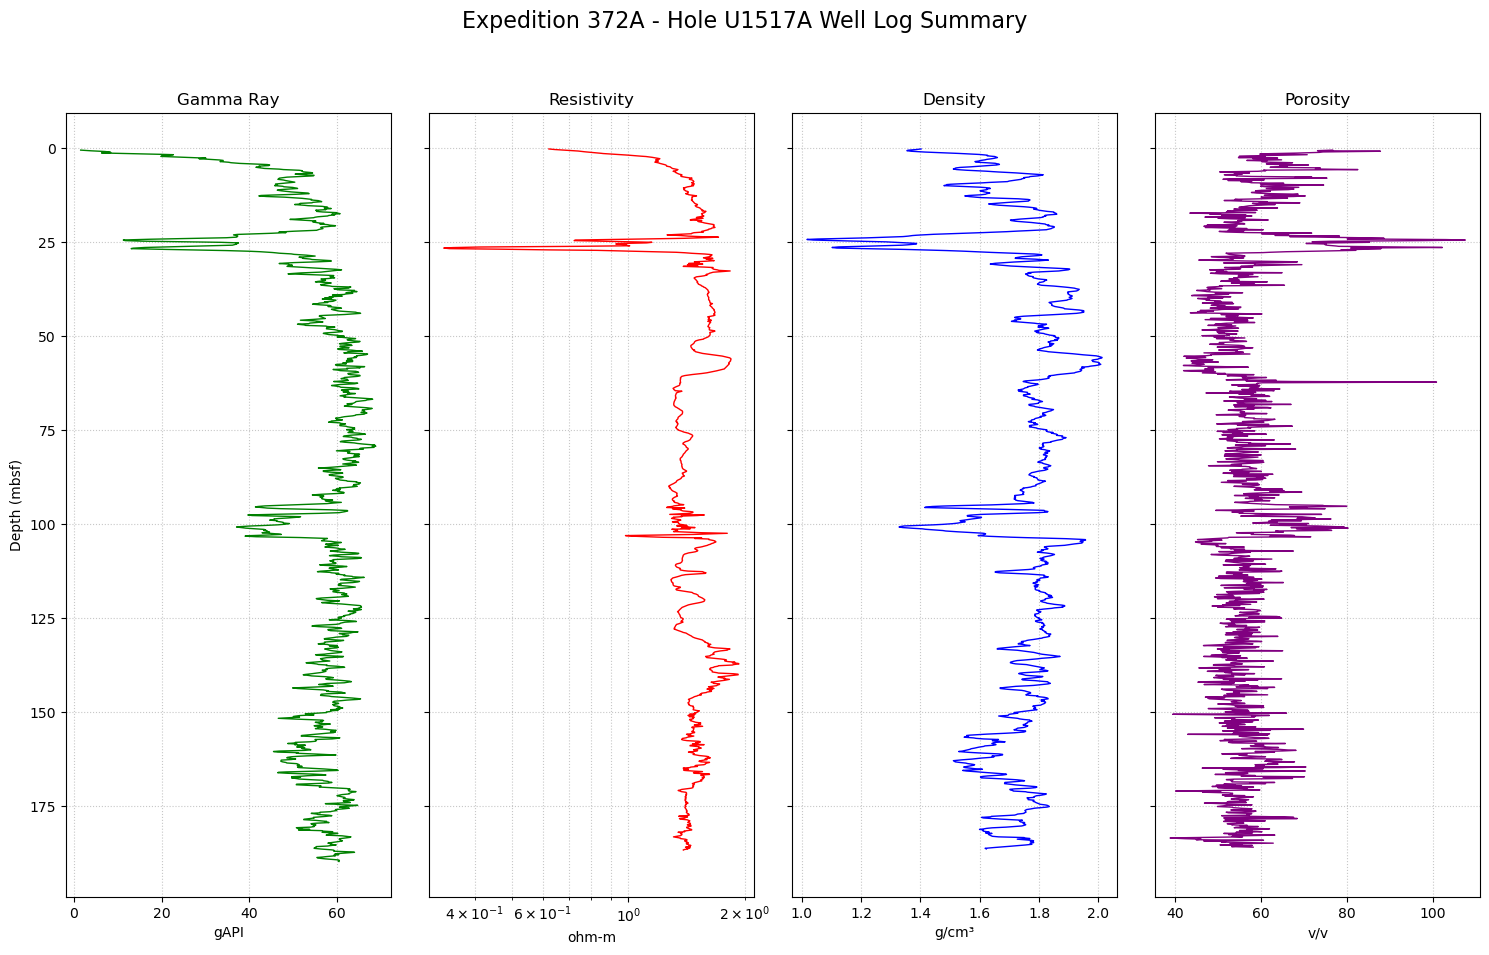

In [5]:
import matplotlib.pyplot as plt

plot_df = df.interpolate(method='linear', limit_area='inside')

fig, ax = plt.subplots(1, 4, figsize=(15, 10), sharey=True)

# Panel 1: Gamma Ray
ax[0].plot(plot_df['grma'], plot_df['depth'], color='green', linewidth=1)
ax[0].set_title('Gamma Ray')
ax[0].set_xlabel('gAPI')

# Panel 2: Resistivity
ax[1].plot(plot_df['a40h'], plot_df['depth'], color='red', linewidth=1)
ax[1].set_title('Resistivity')
ax[1].set_xlabel('ohm-m')
ax[1].set_xscale('log') 

# Panel 3: Density
ax[2].plot(plot_df['rhon'], plot_df['depth'], color='blue', linewidth=1)
ax[2].set_title('Density')
ax[2].set_xlabel('g/cm³')

# Panel 4: Porosity
ax[3].plot(plot_df['tnph'], plot_df['depth'], color='purple', linewidth=1)
ax[3].set_title('Porosity')
ax[3].set_xlabel('v/v')

# Vertical plot formatting
ax[0].invert_yaxis() 
ax[0].set_ylabel('Depth (mbsf)')

# Add grids to all panels
for a in ax:
    a.grid(True, which='both', linestyle=':', alpha=0.7)

plt.suptitle('Expedition 372A - Hole U1517A Well Log Summary', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


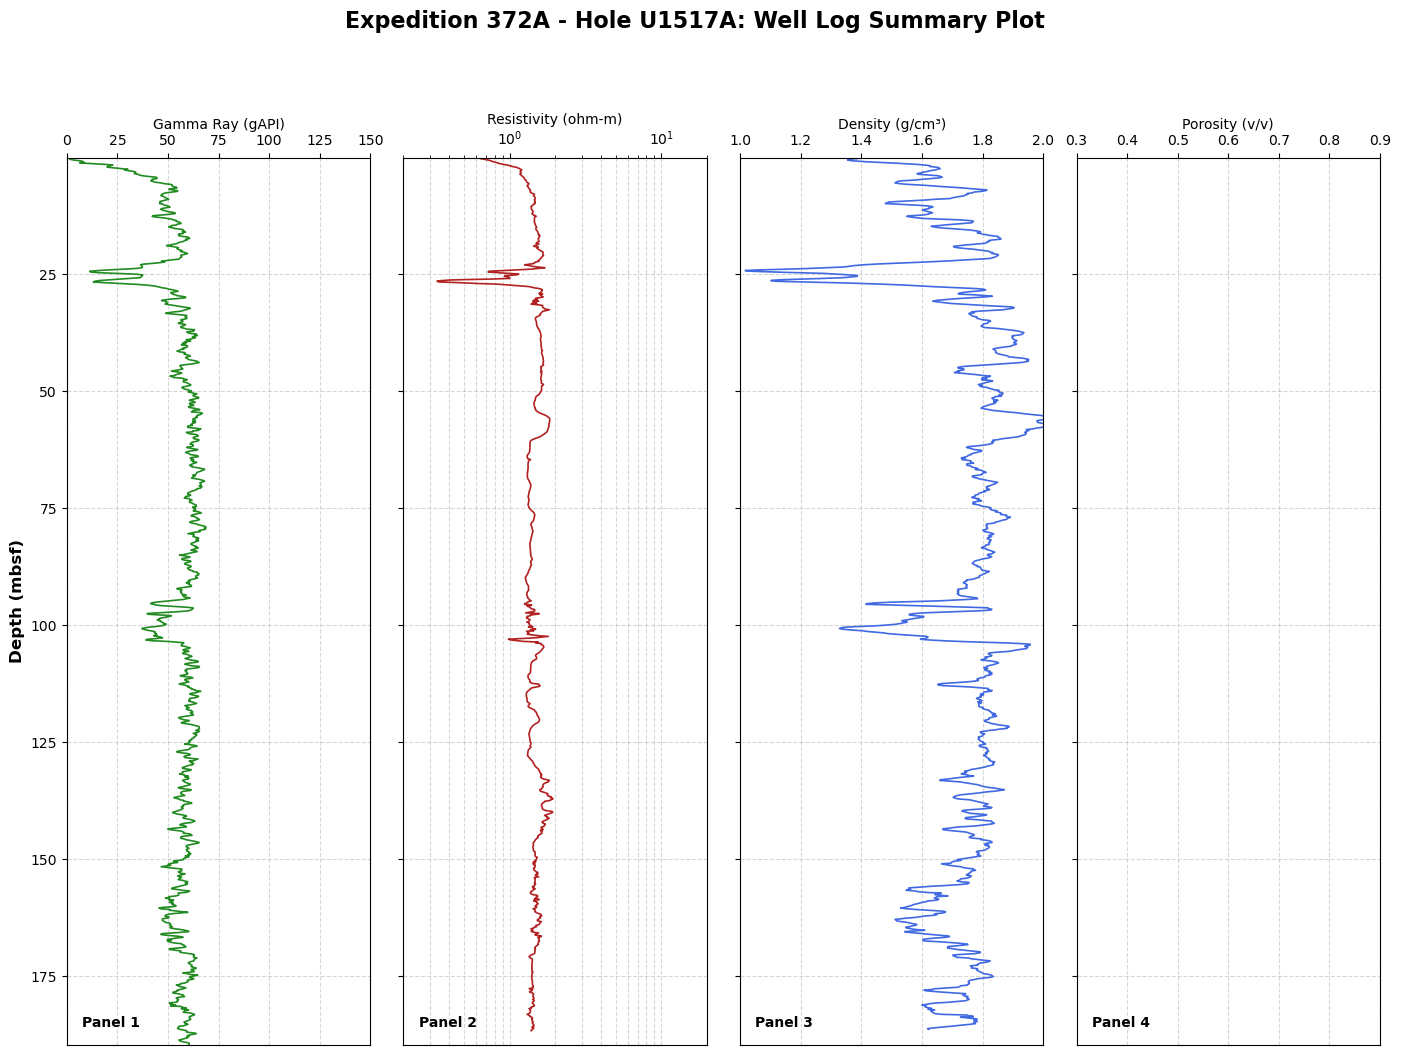

In [6]:

import matplotlib.pyplot as plt

# 1. Prepare the data
plot_df = df.interpolate(method='linear', limit_area='inside')

# 2. Setup the figure with 4 panels
fig, ax = plt.subplots(1, 4, figsize=(14, 10), sharey=True)

# Panel 1: Gamma Ray (Natural Radioactivity)
ax[0].plot(plot_df['grma'], plot_df['depth'], color='forestgreen', linewidth=1.2)
ax[0].set_xlabel('Gamma Ray (gAPI)')
ax[0].set_xlim(0, 150) # Standard range for Gamma Ray

# Panel 2: Resistivity (Logarithmic Scale)
ax[1].plot(plot_df['a40h'], plot_df['depth'], color='firebrick', linewidth=1.2)
ax[1].set_xlabel('Resistivity (ohm-m)')
ax[1].set_xscale('log')
ax[1].set_xlim(0.2, 20) # Typical range for this hole

# Panel 3: Density
ax[2].plot(plot_df['rhon'], plot_df['depth'], color='royalblue', linewidth=1.2)
ax[2].set_xlabel('Density (g/cm³)')
ax[2].set_xlim(1.0, 2.0)

# Panel 4: Porosity
ax[3].plot(plot_df['tnph'], plot_df['depth'], color='darkorchid', linewidth=1.2)
ax[3].set_xlabel('Porosity (v/v)')
ax[3].set_xlim(0.3, 0.9)

# 3. Apply standard Well-Log formatting to all panels
for i, a in enumerate(ax):
    # Move labels and ticks to the top
    a.xaxis.set_label_position('top')
    a.xaxis.tick_top()
    
    # Add a subtle grid
    a.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # Label the panels (A, B, C, D)
    a.text(0.05, 0.02, f'Panel {i+1}', transform=a.transAxes, fontsize=10, fontweight='bold')


ax[0].set_ylim(df['depth'].max(), df['depth'].min()) 
ax[0].set_ylabel('Depth (mbsf)', fontsize=12, fontweight='bold')

# Main Title
plt.suptitle('Expedition 372A - Hole U1517A: Well Log Summary Plot', 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

This summary plot of Hole U1517A can be used to learn a lot about the sub-seabed conditions off the coast of New Zealand. The Gamma Ray log (grma) is relatively elevated throughout the section (primarily in the range of 60-90 gAPI), which can be attributed to a predominantly fine sediment such as silt and clay. We find there is a general tendency, enlarging density (rhon) with decreasing depth, and decreasing porosity (tnph). This is what should occur in the process of sediment compaction in which an overlying weight will squeeze the water out of the pore spaces as the depth increases. One important aspect is the aberrant zone that occurs between about 105 mbsf to 125 mbsf. During this period, there is an observable increase in the resistivity log (a40h) and local variation in the density log. A major indicator of gas hydrates in marine sediments is high resistivity. Owing to their non-conductive properties, gas hydrates act as ice such that they fill the pore space making the formation more electrically resistant. The detection of these layers is one of the main aims of Expedition 372A since the role of gas hydrates in seafloor balance and the world carbon cycle is crucial.
